In [1]:
import pandas as pd

In [5]:
!pip install duckdb
import duckdb

In [7]:
import os
os.getcwd()

'C:\\Users\\anush'

In [17]:
import duckdb

duckdb.sql(r"""
CREATE TABLE funnel1 AS
SELECT *
FROM read_csv_auto("C:\Users\anush\Downloads\funnel_events_sample (1).csv");
""")

In [19]:
duckdb.sql("SHOW TABLES").df()

,name
0,funnel
1,funnel1
2,funnel_events


In [21]:
duckdb.sql("""
SELECT *
FROM funnel1
LIMIT 10;
""").df()

,user_id,step,timestamp
0,U071,signup_started,20-07-2026 04:07
1,U043,signup_started,20-07-2026 04:21
2,U129,visited_site,20-07-2026 03:30
3,U120,purchase_completed,20-07-2026 04:57
4,U115,purchase_completed,20-07-2026 04:56
5,U010,signup_started,20-07-2026 04:09
6,U117,visited_site,20-07-2026 04:02
7,U052,email_verified,20-07-2026 04:48
8,U028,visited_site,20-07-2026 03:44
9,U048,signup_started,20-07-2026 04:24


## Count unique users at each stage¶

In [26]:
duckdb.sql("""
SELECT
    step,
    COUNT(DISTINCT user_id) AS users
FROM funnel1
GROUP BY step;
""").df()

,step,users
0,details_filled,96
1,email_verified,52
2,purchase_completed,44
3,visited_site,200
4,signup_started,150


## Count total events (to detect duplicates)

In [29]:
result = duckdb.sql("""
SELECT
    step,
    COUNT(DISTINCT user_id) AS users
FROM funnel1
GROUP BY step;
""").df()

result

,step,users
0,signup_started,150
1,visited_site,200
2,purchase_completed,44
3,details_filled,96
4,email_verified,52


In [33]:
order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

result["step"] = result["step"].astype("category")
result["step"] = result["step"].cat.set_categories(order, ordered=True)

result = result.sort_values("step")

result

,step,users
1,visited_site,200
0,signup_started,150
3,details_filled,96
4,email_verified,52
2,purchase_completed,44


## Calculate Conversion Rate

In [36]:
result["conversion_rate"] = (
    result["users"] / result["users"].shift(1) * 100
).round(2)

result.loc[result.index[0], "conversion_rate"] = 100

result

,step,users,conversion_rate
1,visited_site,200,100.00
0,signup_started,150,75.00
3,details_filled,96,64.00
4,email_verified,52,54.17
2,purchase_completed,44,84.62


## check dublicate events

In [41]:
duckdb.sql("""
SELECT
    step,
    COUNT(*) AS total_events,
    COUNT(DISTINCT user_id) AS unique_users
FROM funnel1
GROUP BY step;
""").df()

,step,total_events,unique_users
0,email_verified,52,52
1,details_filled,96,96
2,signup_started,150,150
3,visited_site,200,200
4,purchase_completed,44,44


## Check Funnel Stages

In [44]:
duckdb.sql("""
SELECT DISTINCT step
FROM funnel1;
""").df()

,step
0,details_filled
1,signup_started
2,visited_site
3,purchase_completed
4,email_verified


## Users lost

In [49]:
result["users_lost"] = (
    result["users"].shift(1) -
    result["users"]
)

result

,step,users,conversion_rate,users_lost
1,visited_site,200,100.00,NaN
0,signup_started,150,75.00,50.0
3,details_filled,96,64.00,54.0
4,email_verified,52,54.17,44.0
2,purchase_completed,44,84.62,8.0


## Biggest Drop-off¶

In [54]:
lowest = result.loc[result["conversion_rate"].idxmin()]

lowest

step               email_verified
users                          52
conversion_rate             54.17
users_lost                   44.0
Name: 4, dtype: object

## Funnel Analysis Summary
Total users were counted at each funnel stage using COUNT(DISTINCT user_id).
Conversion rates were calculated between consecutive stages.
The biggest drop-off occurred between Details Filled and Email Verified.
This stage has the lowest conversion rate, indicating users are abandoning the process before verifying their email.

In [57]:
biggest = result.loc[result["users_lost"].idxmax()]

print("Biggest drop-off stage:")
print(biggest)

Biggest drop-off stage:
step               details_filled
users                          96
conversion_rate              64.0
users_lost                   54.0
Name: 3, dtype: object


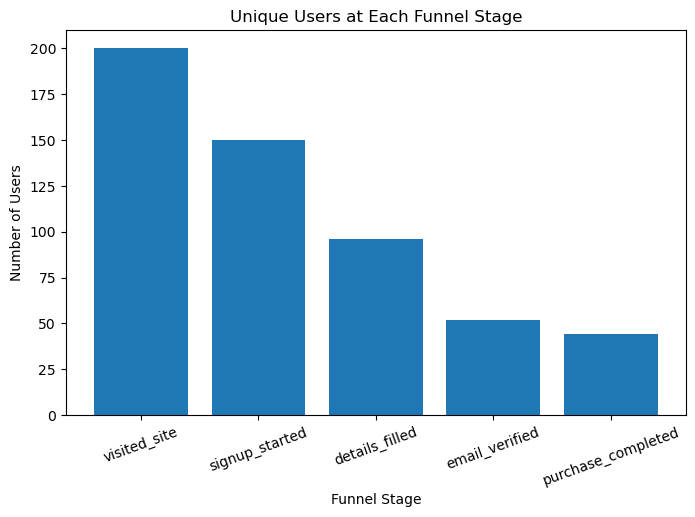

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result["step"], result["users"])

plt.title("Unique Users at Each Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")

plt.xticks(rotation=20)

plt.show()

## Recommendation Note¶
The largest drop-off occurs between Details Filled and Email Verified. 
This suggests users may face friction during the verification process. 
Simplifying email verification or allowing users to continue while verification is pending could improve overall conversion.